### This code is to generate zero-shot fullbody descriptors on CUB dataset by using fullbody segmentation mask generated from Grounding Sam 2.

In [8]:
# Hyperparameters
DEVICE = 3
BATCH_SIZE = 128
IMAGE_SIZE = 320
DATA_DIR = r'/home/c/choton/beemachine/datasets/Others/CUB_200_2011/'

In [9]:
# Import libraries
import os
os.environ["CUDA_VISIBLE_DEVICES"] = str(DEVICE)
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import scipy
# from scipy.fft import fft

from mahotas.features import zernike_moments
from brisque import BRISQUE # NR-IQA
from pypiqe import piqe # NR-IQA

from skimage import img_as_ubyte
from skimage.measure import regionprops, label, shannon_entropy
from skimage.transform import resize
from skimage.color import rgb2gray
from skimage.filters import laplace
from sklearn.model_selection import train_test_split
from skvideo.measure import niqe # NR-IQA

import torch
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Other DL related libraries
import timm
import segmentation_models_pytorch as smp
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection, infer_device
from ultralytics import SAM

# Patch imresize if missing
if not hasattr(scipy.misc, "imresize"):
    def imresize(arr, size, interp=None, mode=None):
        if isinstance(size, float):  # scale factor
            new_shape = (int(arr.shape[0] * size), int(arr.shape[1] * size))
        else:
            new_shape = size[:2]
        arr_resized = resize(arr, new_shape, order=3, mode="reflect", anti_aliasing=True)
        arr_resized = (arr_resized * 255).astype(np.uint8)
        return arr_resized
    scipy.misc.imresize = imresize

# Patch for deprecated NumPy aliases (for backward compatibility)
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'bool'):
    np.bool = bool

In [10]:
# Create SIFT and ORB detectors once
sift = cv2.SIFT_create()
orb = cv2.ORB_create()
bri_obj = BRISQUE(url=False)

def extract_base_features(mask):
    """Compute geometric, Zernike, Fourier, and texture shape descriptors from a binary mask."""
    
    features = ["area", "perimeter", "aspect_ratio", "extent", "solidity", "eccentricity", 
        "orientation", "circularity", "elongation", "compactness"]
    
    if mask is None or mask.sum() == 0:
        return {f: 0 for f in features}

    # --- Region properties ---
    # mask = mask.astype(np.uint8)
    labeled = label(mask)
    props = regionprops(labeled)
    if len(props) == 0:
        return {f: 0 for f in features}
    p = props[0]
    major_axis = p.major_axis_length
    minor_axis = p.minor_axis_length

    # ----- base shape features -----
    area = p.area
    perimeter = max(p.perimeter, 1e-6) # Ignoring too small perimeters
    aspect_ratio = major_axis / minor_axis if minor_axis > 0 else 0 # L_major / L_minor
    extent = p.extent
    solidity = p.solidity
    eccentricity = p.eccentricity
    orientation = p.orientation
    circularity = 4 * np.pi * area / (perimeter ** 2)
    elongation = 1 - (minor_axis / major_axis) if major_axis > 0 else 0
    # convexity = p.perimeter_convex / perimeter
    compactness = (perimeter ** 2) / (4 * np.pi * area + 1e-6)

    # ----- Assemble features -----
    features_d = {
        "area": area,
        "perimeter": perimeter,
        "aspect_ratio": aspect_ratio,
        "extent": extent,
        "solidity": solidity,
        "eccentricity": eccentricity,
        "orientation": orientation,
        "circularity": circularity,
        "elongation": elongation,
        "compactness": compactness
    }
    return features_d

def compute_sift_features(image, mask=None):
    # if isinstance(image, torch.Tensor):
    #     image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    # if isinstance(mask, torch.Tensor):
    #     mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY) # converts image into uint8 and mask as input
    keypoints, descriptors = sift.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 128), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def compute_orb_features(image, mask=None):
    # if isinstance(image, torch.Tensor):
    #     image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    # if isinstance(mask, torch.Tensor):
    #     mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY)
    keypoints, descriptors = orb.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 32), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def compute_hu_moments(mask):
    # if not isinstance(mask, np.ndarray):
    #     mask = mask.numpy().astype(np.uint8)
    moments = cv2.moments(mask)
    hu = cv2.HuMoments(moments).flatten()
    hu = np.log(np.abs(hu) + 1e-12) # log-scale for stability
    return hu

def compute_zernike_moments(mask, degree=8):
    # if not isinstance(mask, np.ndarray):
    #     mask = mask.numpy().astype(np.uint8)
    radius = min(mask.shape) // 2
    mask_norm = mask / mask.max() if mask.max() > 0 else mask
    zern = zernike_moments(mask_norm, radius=radius, degree=degree)
    return zern

# *** Updated fourier descriptors (Dec 4, 2025)
def compute_fourier_descriptors(mask, image=None, fourier_harmonics=20, visualize=False):
    if not isinstance(mask, np.ndarray): # Ensure proper mask format
        mask = mask.numpy().astype(np.uint8)
    # --- 2. Find largest contour (object part) ---
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    cnt = max(contours, key=cv2.contourArea)
    if len(cnt) < 3:
        # Too few points for Fourier transform
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    
    # Translation invariance: center contour
    complex_contour = cnt[:,0,0] + 1j * cnt[:,0,1]
    fd = np.fft.fft(complex_contour)
    
    if visualize: # ** IMPORTANT: Visualization uses raw contour (so you can see the real shape), descriptors are centered.
        # Convert image if needed
        H, W = mask.shape
        if image is not None:
            if isinstance(image, torch.Tensor):
                image = image.detach().cpu().numpy().transpose(1, 2, 0)
            elif isinstance(image, Image.Image):
                image = np.array(image.convert('RGB'))
            elif image.dtype != np.uint8:  # NumPy float → uint8
                image = (image*255).astype(np.uint8)
            img_draw = image.copy()
        else:
            img_draw = np.zeros((H, W, 3), dtype=np.uint8)
        cv2.drawContours(img_draw, [cnt.astype(np.int32)], -1, (0, 255, 0), 2)

        fd_recon = fd.copy()
        keep = fourier_harmonics
        if 2 * keep < len(fd_recon):
            fd_recon[keep:-keep] = 0 # Safe zeroing
        else:
            fd_recon[keep:] = 0
        recon = np.fft.ifft(fd_recon)
        pts = np.column_stack((recon.real, recon.imag)).astype(np.int32)

        for i in range(len(pts)):
            cv2.line(img_draw, tuple(pts[i]), tuple(pts[(i + 1) % len(pts)]), (255, 0, 255), 1)
        plt.figure(figsize=(16, 6))
        plt.imshow(img_draw)
        plt.axis('off')
        plt.title("Shape Descriptors Overlay")
        plt.legend(
            handles=[
                Patch(facecolor='green', edgecolor='green'),
                Patch(facecolor='magenta', edgecolor='magenta')
            ],
            labels=["Contour", "Fourier Reconstruction"],
            loc='upper right'
        )
        plt.show()
    
    cnt_centered = complex_contour - np.mean(complex_contour)
    fd = np.fft.fft(cnt_centered)
    if len(fd) < 2 or np.abs(fd[1]) == 0:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)

    # Scale invariance: divide by first descriptor magnitude
    fd = fd / np.abs(fd[1])

    # Rotation invariance: use only magnitudes
    fd_normalized = np.abs(fd)

    # Keep only first N harmonics
    fd_truncated = fd_normalized[:fourier_harmonics]
    if len(fd_truncated) < fourier_harmonics:
        fd_truncated = np.concatenate([fd_truncated, np.full((fourier_harmonics - len(fd_truncated)), np.nan)])
    return fd_truncated

def extract_shape_features(image, mask):
    # Compute base features
    features = extract_base_features(mask)

    # Compute sift features
    sift_kp, sift_ds = compute_sift_features(image, mask)
    sift_sizes = [k.size for k in sift_kp]
    if sift_ds.shape[0] > 0:
        sift_mean_ds = np.nanmean(sift_ds, axis=0)
    else:
        sift_mean_ds = np.full(128, np.nan)
    sift_dict = {f'sift_ds{i+1}': sift_mean_ds[i] for i in range(len(sift_mean_ds))}
    sift_dict['sift_kp_n'] = len(sift_kp)
    sift_dict['sift_kp_size'] = np.max(sift_sizes) if sift_sizes else 0

    # Compute orb features
    orb_kp, orb_ds = compute_orb_features(image, mask)
    if orb_ds.shape[0] > 0:
        orb_mean_ds = np.nanmean(orb_ds, axis=0)
    else:
        orb_mean_ds = np.full(32, np.nan)
    orb_dict = {f'orb_ds{i+1}': orb_mean_ds[i] for i in range(len(orb_mean_ds))}
    orb_dict['orb_kp_n'] = len(orb_kp)

    # Compute hu moments
    hu_moments = compute_hu_moments(mask)
    hu_dict = {f"hu{i+1}": hu_moments[i] for i in range(len(hu_moments))}

    # Compute Zernike moments
    zern_moments = compute_zernike_moments(mask, degree=8)
    zern_dict = {f"zernike_{i+1}": zern_moments[i] for i in range(len(zern_moments))}

    # Compute fourier descriptors
    fourier_ds = compute_fourier_descriptors(mask, fourier_harmonics=20)
    fourier_dict = {f"fourier_{i+1}": fourier_ds[i] for i in range(len(fourier_ds))}

    features.update(sift_dict)
    features.update(orb_dict)
    features.update(hu_dict)
    features.update(zern_dict)
    features.update(fourier_dict)
    converted = {k: np.float32(v) for k, v in features.items()}
    return converted

def extract_visual_features(image, mask):
    # --- 1. Ensure binary uint8 mask ---
    if not isinstance(mask, np.ndarray):
        mask = mask.numpy().astype(np.uint8)
    # Convert image to numpy
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    elif isinstance(image, Image.Image):
        image = np.array(image.convert('RGB'))
    img_cropped = np.zeros_like(image)
    img_cropped[mask==1] = image[mask==1]
    # plt.imshow(img_cropped)

    # --- Brightness ---
    brightness = np.mean(img_cropped)

    # --- Contrast (standard deviation of luminance) ---
    gray = rgb2gray(img_cropped)
    contrast = np.std(gray)

    # --- Sharpness (variance of Laplacian) ---
    gray_8u = (gray * 255).astype(np.uint8)
    lap_var = cv2.Laplacian(gray_8u, cv2.CV_64F).var()

    # --- Colorfulness (Hasler & Süsstrunk, 2003) ---
    (R, G, B) = cv2.split(img_cropped)
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)
    std_rg, std_yb = np.std(rg), np.std(yb)
    mean_rg, mean_yb = np.mean(rg), np.mean(yb)
    colorfulness = np.sqrt(std_rg**2 + std_yb**2) + 0.3 * np.sqrt(mean_rg**2 + mean_yb**2)

    # --- Entropy (texture complexity) ---
    entropy = shannon_entropy(gray)

    # BRISQUE
    bri_obj = BRISQUE(url=False)
    brisque_score = bri_obj.score(img_cropped)

    # NIQE
    niqe_score = niqe(gray)

    # PIQE
    piqe_score, activityMask, noticeableArtifactMask, noiseMask = piqe(gray)

    # --- Aggregate descriptors ---
    descriptors = {
        "brightness": np.float32(brightness),
        "contrast": np.float32(contrast),
        "sharpness": np.float32(lap_var),
        "colorfulness": np.float32(colorfulness),
        "entropy": np.float32(entropy),
        "brisque": np.float32(brisque_score),
        "niqe": np.float32(niqe_score.item()),
        "piqe": np.float32(piqe_score)
    }
    return descriptors

In [11]:
def extract_combined_features(image, mask): 
    # ---- Convert once ----
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy().astype(np.uint8)
    if (mask is None) or (mask.size == 0) or (not mask.any()):
        return {}
    mask_u8 = mask.astype(np.uint8)
    image_f = (image - image.min()) / (image.max() - image.min() + 1e-8) # Linearly rescale to [0, 1] and avoid division by zero
    image_u8 = img_as_ubyte(image_f)

    combined_features = extract_shape_features(image_u8, mask_u8)
    vis_features = extract_visual_features(image_f, mask_u8)
    combined_features.update(vis_features)
    return combined_features

In [12]:
# Load the GroundingDINO model
model_dino_id = "IDEA-Research/grounding-dino-base"
device = infer_device()
processor = AutoProcessor.from_pretrained(model_dino_id)
model_dino = AutoModelForZeroShotObjectDetection.from_pretrained(model_dino_id).to(device)

# Load the SAM 2 model
model_sam2 = SAM("/home/c/choton/beemachine/codes/sam2_ultralytics_weights/sam2.1_b.pt")

In [13]:
def generate_full_body_mask(image_path, text_prompt):
    no_box, no_mask = False, False 
    try:
        image = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Failed to open image: {image_path}, {e}")
        return None

    text_labels = [[text_prompt]]
    W, H = image.size
    nan_mask = np.full((H, W), np.nan, dtype=float)
    
    try:
        # Grounding DINO
        inputs = processor(images=image, text=text_labels, return_tensors="pt").to(model_dino.device)
        with torch.no_grad():
            outputs = model_dino(**inputs)

        results = processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            threshold=0.35,
            text_threshold=0.25,
            target_sizes=[image.size[::-1]]
        )       
        boxes = results[0].get("boxes", None)
    except Exception as e:
        print(f"GroundingDINO failure on {image_path}: {e}")
        boxes = None
        no_box = True    
    if boxes is None or len(boxes) == 0:
        # ← fallback: full-image box for SAM2
        # print("No object detected using DINO for image:", image_path)
        w, h = image.size
        box = np.array([0, 0, w, h], dtype=np.float32)
        no_box = True
    else:
        box = boxes[0].cpu().numpy()    
    try:
        # Use SAM 2 and generate masks
        results = model_sam2(image_path, bboxes=[box], verbose=False) # This will return a single, most confident mask for the given prompt
        masks = results[0].masks.data.cpu().numpy()
        if masks.shape[0] > 1: 
            # choose best mask, e.g. by area
            areas = [mask.sum() for mask in masks]
            idx = np.argmax(areas)
            mask = masks[idx]
        else:
            mask = masks[0]
    except Exception as e:
        print(f"SAM2 failure on {image_path}: {e}")
        mask = nan_mask
        no_mask = True
    if (mask is None) or (mask.size == 0) or (not mask.any()):
        print("No mask detected using SAM 2 for image:", image_path)
        mask = nan_mask
        no_mask = True
    return mask, no_box, no_mask #, image_mask

In [14]:
images = os.listdir(os.path.join(DATA_DIR, 'images'))

Total images: 11788


/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/ultralytics/models/sam/predict.py:318: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  bboxes = torch.as_tensor(bboxes, dtype=self.torch_dtype, device=self.device)


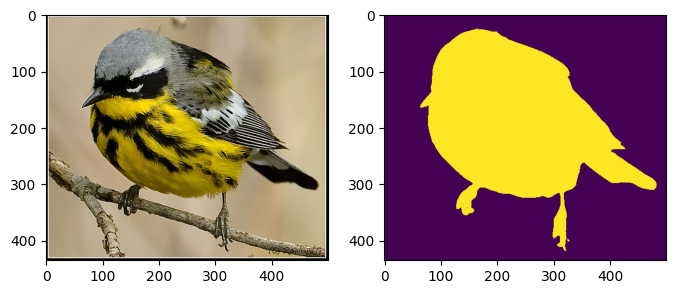

In [15]:
class_dirs = os.listdir(os.path.join(DATA_DIR, 'images'))
image_paths = []
for cdir in class_dirs:
    imgs = os.listdir(os.path.join(DATA_DIR, 'images', cdir))
    paths = [os.path.join(DATA_DIR, 'images', cdir, f) for f in imgs]
    image_paths += paths
print("Total images:", len(image_paths))

# Image path for zero-shot analysis
image_path = image_paths[633]
image = Image.open(image_path)
text_prompt = r"bird"

mask, _, _ = generate_full_body_mask(image_path, text_prompt)
fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(image)
axes[1].imshow(mask)

In [16]:
mask.shape

(435, 500)

In [18]:
def read_part_labels(path):
    with open(path) as f:
        labels = [l.strip() for l in f if l.strip()]
        return labels

class PartWholeDataset(Dataset):
    def __init__(self, root, images_dir="images", image_size=320):
        self.images_dir = os.path.join(root, images_dir)
        IMAGE_SIZE = image_size

        # -------- Labels --------
        self.labels = ["background"] + read_part_labels(
            os.path.join(root, "part_labels.txt")
        )
        self.num_parts = len(self.labels)

        # class folders
        self.classes = sorted(os.listdir(self.images_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        # collect image paths WITH class
        self.samples = []
        for c in self.classes:
            cls_img_dir = os.path.join(self.images_dir, c)
            for fname in os.listdir(cls_img_dir):
                if fname.lower().endswith((".jpg", ".png", ".jpeg")):
                    img_path = os.path.join(cls_img_dir, fname)
                    self.samples.append((img_path, self.class_to_idx[c]))
        self.samples = sorted(self.samples)

        # image transform
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size),
                              interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, class_id = self.samples[idx]

        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)

        return img, img_path, class_id

In [19]:
# Create Dataset
full_dataset = PartWholeDataset(root=DATA_DIR, images_dir="images", image_size=IMAGE_SIZE)
torch.manual_seed(42)
print("Total images:", len(full_dataset))

Total images: 11788


In [20]:
image, img_path, _ = full_dataset[8]
text_prompt = 'bird'
mask, no_box, no_mask = generate_full_body_mask(img_path, text_prompt)
if mask is None:
    mask = np.full((IMAGE_SIZE, IMAGE_SIZE), np.nan, dtype=np.float32)
if mask.ndim > 2:
    mask = mask.squeeze() # Make the mask 2D
mask = torch.from_numpy(np.array(mask, dtype=np.float32))
mask = mask.unsqueeze(0).unsqueeze(0)  # (1,1,H,W) for interpolate
mask = torch.nn.functional.interpolate(mask, size=(IMAGE_SIZE,IMAGE_SIZE), mode='nearest')  # keep discrete values
mask = mask.squeeze(0).squeeze(0)  # back to (H,W)

s_feats = extract_combined_features(image=image, mask=mask)
print(s_feats)
s_df = pd.DataFrame.from_dict([s_feats])
s_df

{'area': np.float32(5750.0), 'perimeter': np.float32(516.8183), 'aspect_ratio': np.float32(1.411567), 'extent': np.float32(0.30416843), 'solidity': np.float32(0.53418803), 'eccentricity': np.float32(0.70577854), 'orientation': np.float32(-0.2378091), 'circularity': np.float32(0.27052158), 'elongation': np.float32(0.29156747), 'compactness': np.float32(3.696563), 'sift_ds1': np.float32(12.478261), 'sift_ds2': np.float32(16.717392), 'sift_ds3': np.float32(28.673914), 'sift_ds4': np.float32(30.97826), 'sift_ds5': np.float32(24.043478), 'sift_ds6': np.float32(12.565217), 'sift_ds7': np.float32(7.826087), 'sift_ds8': np.float32(9.0), 'sift_ds9': np.float32(52.326088), 'sift_ds10': np.float32(30.065218), 'sift_ds11': np.float32(22.826086), 'sift_ds12': np.float32(25.413044), 'sift_ds13': np.float32(20.913044), 'sift_ds14': np.float32(16.282608), 'sift_ds15': np.float32(13.543478), 'sift_ds16': np.float32(15.369565), 'sift_ds17': np.float32(74.521736), 'sift_ds18': np.float32(24.804348), 'sif

,area,perimeter,aspect_ratio,extent,solidity,eccentricity,orientation,circularity,elongation,compactness,...,fourier_19,fourier_20,brightness,contrast,sharpness,colorfulness,entropy,brisque,niqe,piqe
0,5750.0,516.818298,1.411567,0.304168,0.534188,0.705779,-0.237809,0.270522,0.291567,3.696563,...,0.054104,0.016944,0.016833,0.07646,419.901581,0.017117,0.953189,100.553284,26.488214,57.338776


**Note**: For each part, we have 225 shape descriptors and 8 visual descriptors (233 in total). We have 5 inter-part ratios in here. After dropping all part columns (head, thorax, abdomen), we have = 937 - (233*3) - 5 = 233 columns (verify in the previous cell outputs).

In [21]:
def extract_features_for_dataset(dataset, output_csv, text_prompt='bird'):
    records = []
    no_boxes, no_masks = 0, 0
    print(f"Extracting shape features for {len(dataset)} images...")
    pbar = tqdm(dataset, desc=f"empty_boxes={no_boxes}, empty_masks={no_masks}")
    for image, img_path, class_id in pbar:
        mask, no_box, no_mask = generate_full_body_mask(img_path, text_prompt)
        if mask is None:
            mask = np.full((IMAGE_SIZE, IMAGE_SIZE), np.nan, dtype=np.float32)
        if mask.ndim > 2:
            mask = mask.squeeze() # Make the mask 2D
        mask = torch.from_numpy(np.array(mask, dtype=np.float32))
        mask = mask.unsqueeze(0).unsqueeze(0)  # (1,1,H,W) for interpolate
        mask = torch.nn.functional.interpolate(mask, size=(IMAGE_SIZE,IMAGE_SIZE), mode='nearest')  # keep discrete values
        mask = mask.squeeze(0).squeeze(0)  # back to (H,W)

        if no_box:
            no_boxes += 1
            pbar.set_description(f"empty_boxes={no_boxes}, empty_masks={no_masks}")
        if no_mask:
            no_masks += 1
            pbar.set_description(f"empty_boxes={no_boxes}, empty_masks={no_masks}")            
        features = extract_combined_features(image=image, mask=mask)
        record = {"image": os.path.basename(img_path),
                  "class_id": class_id}
        record.update(features)
        records.append(record)

    df = pd.DataFrame(records)
    df.to_csv(output_csv, index=False)
    print(f"✅ Saved shape features to: {output_csv}")
    return df

In [22]:
feat_path = r"./cub_zeroshot_fullbody_features_concise"
os.makedirs(feat_path, exist_ok=True)

In [23]:
full_csv = os.path.join(feat_path, r"cub_zeroshot_fullbody_features.csv")
df = extract_features_for_dataset(full_dataset, full_csv)
df

Extracting shape features for 11788 images...


empty_boxes=2, empty_masks=0: 100%|██████████| 11788/11788 [2:45:31<00:00,  1.19it/s] 


✅ Saved shape features to: ./cub_zeroshot_fullbody_features_concise/cub_zeroshot_fullbody_features.csv


,image,class_id,area,perimeter,aspect_ratio,extent,solidity,eccentricity,orientation,circularity,...,fourier_19,fourier_20,brightness,contrast,sharpness,colorfulness,entropy,brisque,niqe,piqe
0,Black_Footed_Albatross_0001_796111.jpg,0,8629.0,784.724976,3.033663,0.240309,0.480644,0.944109,0.749800,0.176090,...,0.008369,0.004568,0.029006,0.104615,794.666687,0.025002,1.419944,100.554306,26.000183,62.879032
1,Black_Footed_Albatross_0002_55.jpg,0,19134.0,892.595032,1.876601,0.412655,0.646506,0.846192,-1.184245,0.301791,...,0.002984,0.000662,0.082881,0.191822,550.632568,0.093798,3.318228,60.814404,25.853428,44.957020
2,Black_Footed_Albatross_0003_796136.jpg,0,9081.0,780.671143,3.220716,0.265759,0.456446,0.950577,-0.312261,0.187244,...,0.003415,0.004746,0.017526,0.070281,783.811462,0.016336,1.463843,98.253235,26.652092,56.779533
3,Black_Footed_Albatross_0005_796090.jpg,0,15168.0,1432.378906,1.595000,0.170504,0.360756,0.779052,-0.791375,0.092901,...,0.023523,0.026129,0.044954,0.129635,1632.132690,0.031176,2.620265,106.660637,25.819269,59.061398
4,Black_Footed_Albatross_0006_796065.jpg,0,6787.0,731.251892,2.699541,0.187217,0.401170,0.928859,0.914471,0.159497,...,0.010756,0.007131,0.017098,0.072913,545.434448,0.017289,1.184897,107.253754,26.572536,58.659615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11783,Common_Yellowthroat_0118_190805.jpg,199,6932.0,630.848816,2.408649,0.319197,0.527389,0.909744,-0.451936,0.218886,...,0.005747,0.026475,0.021803,0.099664,578.198181,0.074834,1.213182,106.692276,26.457121,56.473396
11784,Common_Yellowthroat_0121_190597.jpg,199,5109.0,531.859985,2.701163,0.493623,0.789767,0.928948,-0.191191,0.226961,...,0.006054,0.011553,0.033812,0.145275,750.116760,0.079754,1.400528,109.447784,25.229189,67.382309
11785,Common_Yellowthroat_0122_190570.jpg,199,10780.0,708.109741,1.650997,0.448998,0.623193,0.795697,-0.673230,0.270164,...,0.036237,0.023151,0.035768,0.127935,350.367493,0.085206,1.883815,94.812347,26.284130,44.434917
11786,Common_Yellowthroat_0125_190902.jpg,199,10891.0,627.913757,1.679510,0.434666,0.779822,0.803421,0.809411,0.347118,...,0.010843,0.002922,0.064947,0.195942,772.234375,0.112180,2.305209,87.186096,25.916109,53.815681
